# 📊 EDA — Empleo por Calificación
**Fuente:** `e_por_calificacion.csv`  
**Descripción:** Empleo dependiente privado mensual en Perú según nivel de calificación del trabajador (Calificado, No Calificado, No Especificado). Período 2015–2025.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from io import StringIO

# Configuración de estilo
plt.rcParams.update({'figure.dpi': 130, 'font.family': 'DejaVu Sans'})
sns.set_theme(style='whitegrid', palette='muted')
COLORS = {'calificado': '#4C72B0', 'no_calificado': '#DD8452', 'no_esp': '#8172B2'}
print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


## 1. Carga y Limpieza de Datos

In [2]:
# Leer CSV con separador ; y encabezado multilinea
raw = open('e_por_calificacion.csv', 'r', encoding='utf-8').read()

df = pd.read_csv(
    'e_por_calificacion.csv',
    sep=';',
    encoding='utf-8',
    header=0,
    on_bad_lines='skip'
)

# Limpiar nombres de columnas (pueden tener saltos de línea)
df.columns = df.columns.str.replace('\n', ' ', regex=False).str.strip()

# Renombrar columnas
df.columns = ['anio', 'mes', 'calificado', 'no_calificado', 'no_especificado']

# Convertir valores numéricos (formato con comas como miles)
for col in ['calificado', 'no_calificado', 'no_especificado']:
    df[col] = df[col].astype(str).str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Limpiar filas sin datos
df.dropna(subset=['calificado'], inplace=True)
df['anio'] = df['anio'].astype(int)

# Mapa de meses para orden correcto
mes_orden = {'ENE.':1,'FEB.':2,'MAR.':3,'ABR.':4,'MAY.':5,'JUN.':6,
             'JUL.':7,'AGO.':8,'SET.':9,'OCT.':10,'NOV.':11,'DIC.':12}
df['mes_num'] = df['mes'].map(mes_orden)
df['fecha'] = pd.to_datetime(df['anio'].astype(str) + '-' + df['mes_num'].astype(str).str.zfill(2), format='%Y-%m')
df.sort_values('fecha', inplace=True)
df.reset_index(drop=True, inplace=True)

# Variable total
df['total'] = df['calificado'] + df['no_calificado'] + df['no_especificado']

print(f'Shape: {df.shape}')
df.head()

Shape: (128, 8)


,anio,mes,calificado,no_calificado,no_especificado,mes_num,fecha,total
0,2015,ENE.,668671,2457994,3690,1,2015-01-01,3130355
1,2015,FEB.,669908,2444861,3742,2,2015-02-01,3118511
2,2015,MAR.,707895,2458398,3762,3,2015-03-01,3170055
3,2015,ABR.,738337,2418037,55409,4,2015-04-01,3211783
4,2015,MAY.,741721,2418401,59104,5,2015-05-01,3219226


## 2. Estadísticas Descriptivas

In [3]:
desc = df[['calificado','no_calificado','no_especificado','total']].describe().round(0)
desc.index = ['Conteo','Media','Desv. Est.','Mín','Q25','Mediana','Q75','Máx']
desc

,calificado,no_calificado,no_especificado,total
Conteo,128.0,128.0,128.0,128.0
Media,805114.0,2805743.0,28097.0,3638953.0
Desv. Est.,108261.0,275814.0,35710.0,369698.0
Mín,648066.0,2091347.0,3690.0,2810882.0
Q25,723050.0,2598985.0,12018.0,3351678.0
Mediana,767546.0,2744554.0,20344.0,3556945.0
Q75,888436.0,2995813.0,26819.0,3919678.0
Máx,1041062.0,3426828.0,254478.0,4454406.0


In [4]:
# Valores nulos
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nRango temporal: {df["fecha"].min().strftime("%b %Y")} → {df["fecha"].max().strftime("%b %Y")}')
print(f'Años cubiertos: {sorted(df["anio"].unique())}')

Valores nulos por columna:
anio               0
mes                0
calificado         0
no_calificado      0
no_especificado    0
mes_num            0
fecha              0
total              0
dtype: int64

Rango temporal: Jan 2015 → Aug 2025
Años cubiertos: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


## 3. Serie de Tiempo — Evolución del Empleo por Calificación

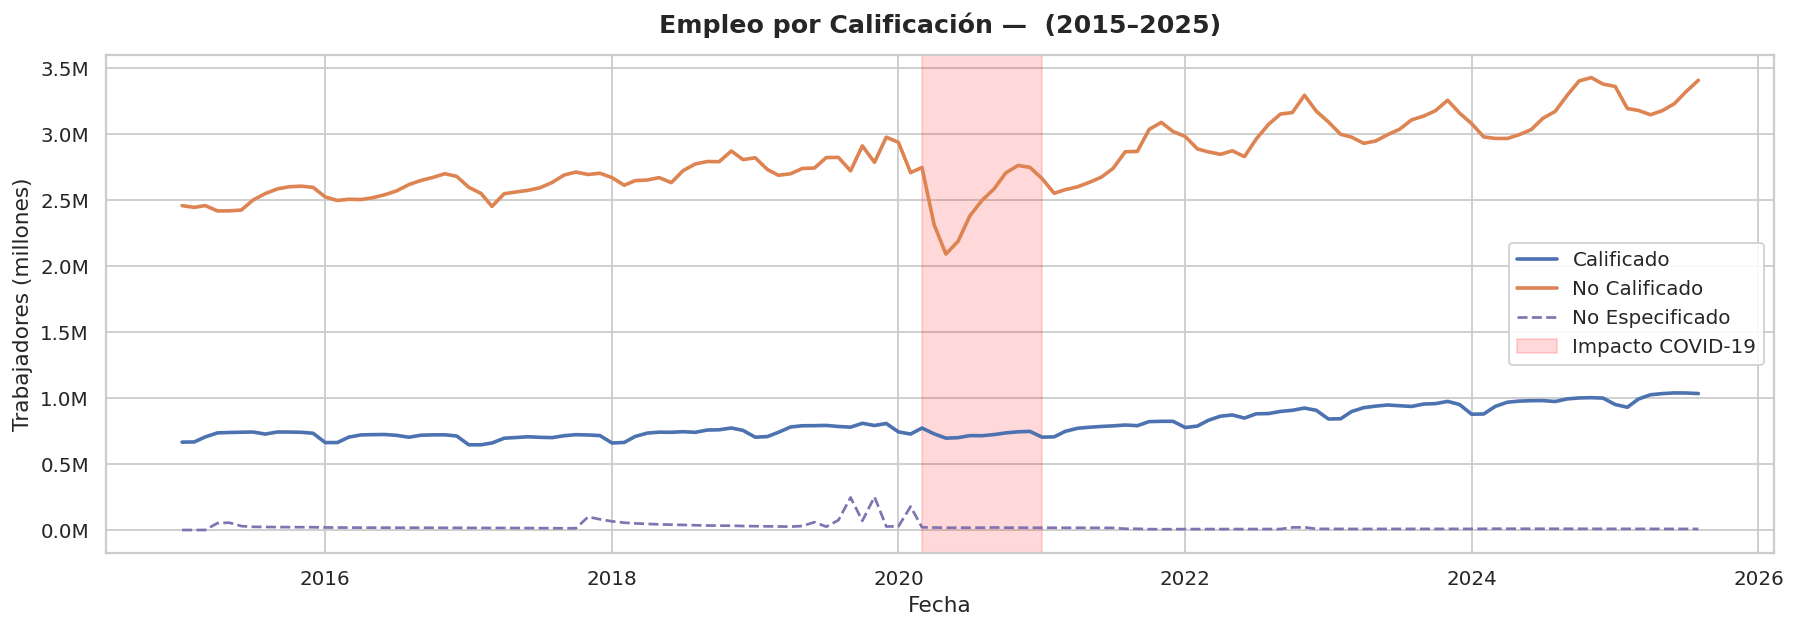

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['fecha'], df['calificado']/1e6, label='Calificado', color=COLORS['calificado'], lw=2)
ax.plot(df['fecha'], df['no_calificado']/1e6, label='No Calificado', color=COLORS['no_calificado'], lw=2)
ax.plot(df['fecha'], df['no_especificado']/1e6, label='No Especificado', color=COLORS['no_esp'], lw=1.5, ls='--')

# Sombrear COVID-19
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-31'),
           alpha=0.15, color='red', label='Impacto COVID-19')

ax.set_title('Empleo por Calificación —  (2015–2025)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Fecha')
ax.set_ylabel('Trabajadores (millones)')
ax.legend(framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
plt.tight_layout()
plt.show()

## 4. Promedio Anual por Categoría

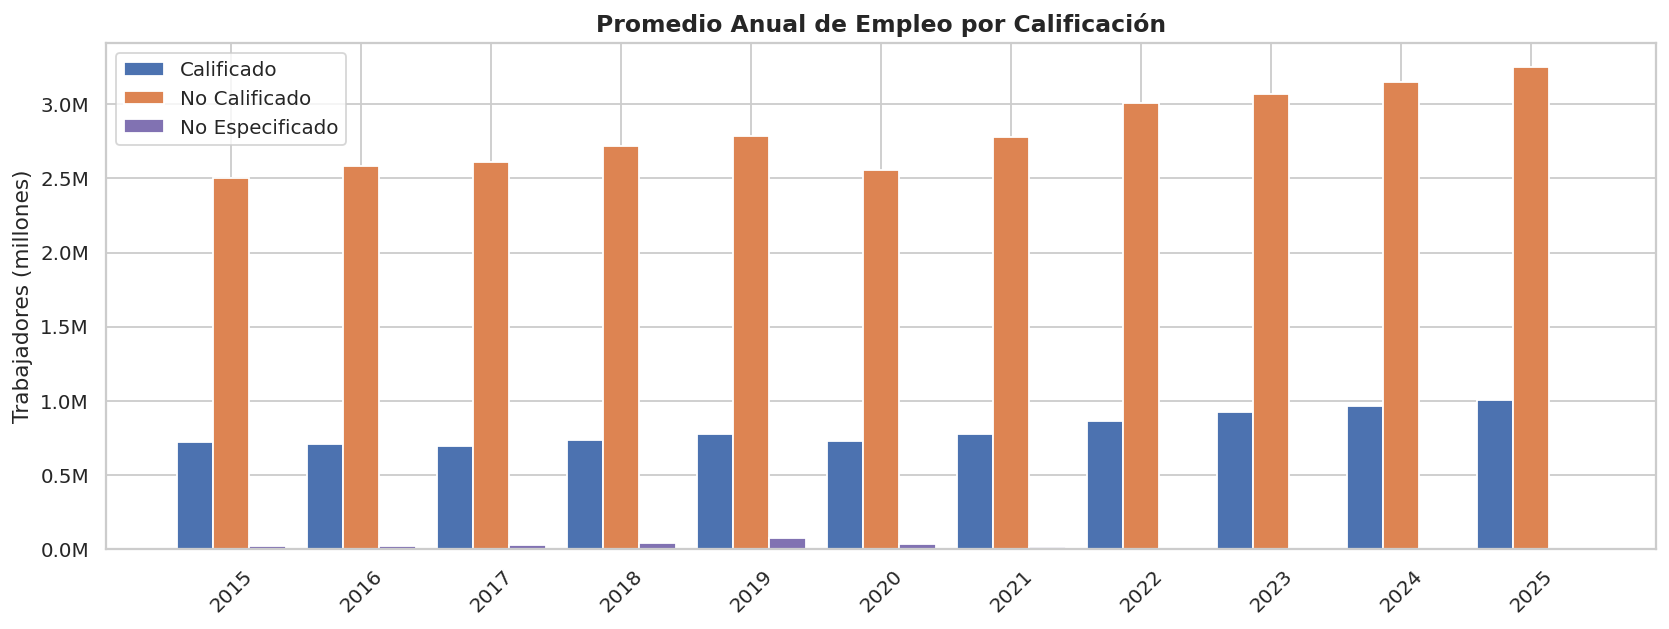

In [7]:
anual = df.groupby('anio')[['calificado','no_calificado','no_especificado']].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(anual))
w = 0.28
bars1 = ax.bar(x - w, anual['calificado']/1e6, w, label='Calificado', color=COLORS['calificado'])
bars2 = ax.bar(x,      anual['no_calificado']/1e6, w, label='No Calificado', color=COLORS['no_calificado'])
bars3 = ax.bar(x + w,  anual['no_especificado']/1e6, w, label='No Especificado', color=COLORS['no_esp'])

ax.set_xticks(x)
ax.set_xticklabels(anual['anio'].astype(int), rotation=45)
ax.set_title('Promedio Anual de Empleo por Calificación', fontsize=13, fontweight='bold')
ax.set_ylabel('Trabajadores (millones)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.legend()
plt.tight_layout()
plt.show()

## 5. Participación Porcentual (sin 'No Especificado')

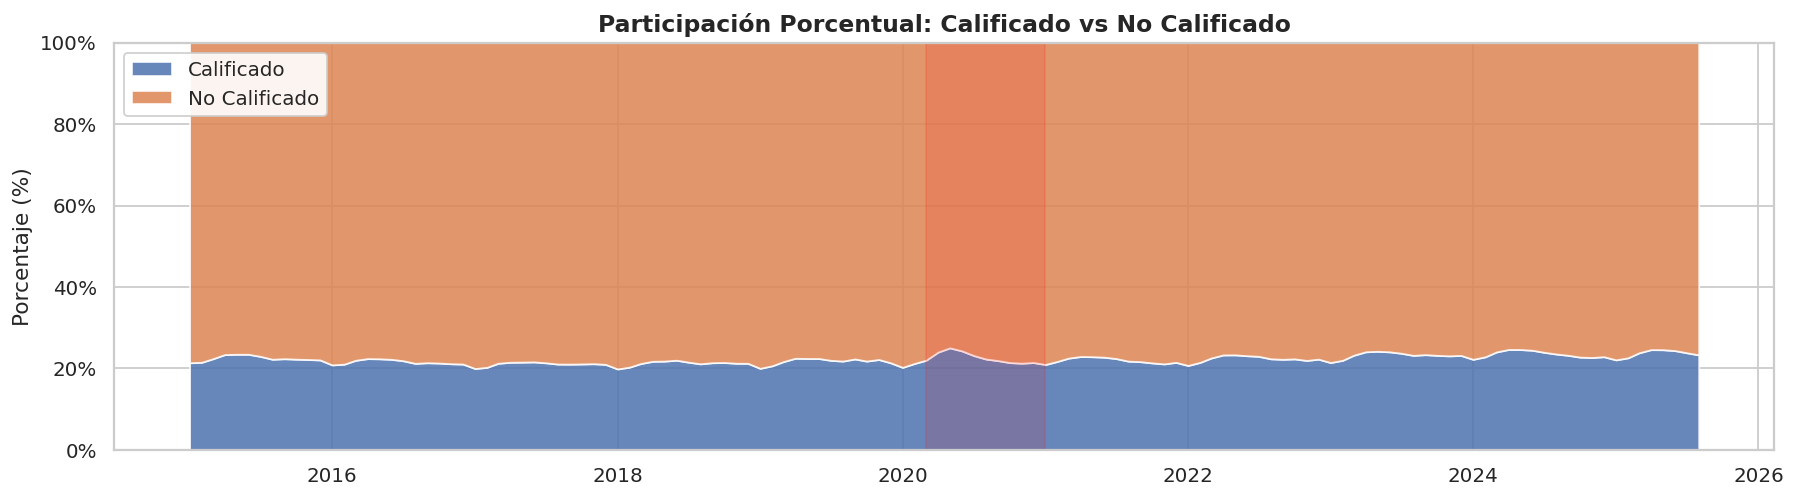

In [8]:
df['total_2cat'] = df['calificado'] + df['no_calificado']
df['pct_calificado'] = df['calificado'] / df['total_2cat'] * 100
df['pct_no_calificado'] = df['no_calificado'] / df['total_2cat'] * 100

fig, ax = plt.subplots(figsize=(14, 4))
ax.stackplot(df['fecha'],
             df['pct_calificado'], df['pct_no_calificado'],
             labels=['Calificado', 'No Calificado'],
             colors=[COLORS['calificado'], COLORS['no_calificado']],
             alpha=0.85)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-31'), alpha=0.12, color='red')
ax.set_title('Participación Porcentual: Calificado vs No Calificado', fontsize=13, fontweight='bold')
ax.set_ylabel('Porcentaje (%)')
ax.set_ylim(0, 100)
ax.legend(loc='upper left', framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

## 6. Estacionalidad Mensual

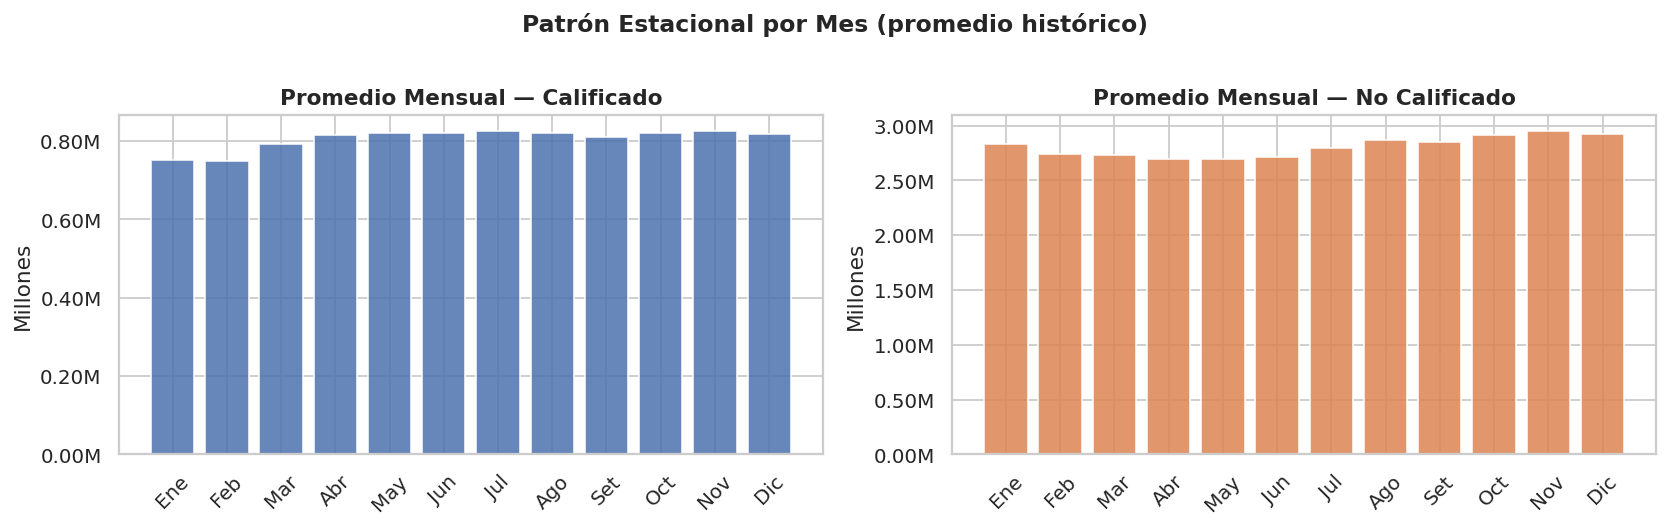

In [9]:
estac = df.groupby('mes_num')[['calificado','no_calificado']].mean()
meses_etiquetas = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Set','Oct','Nov','Dic']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, color, titulo in zip(
    axes,
    ['calificado', 'no_calificado'],
    [COLORS['calificado'], COLORS['no_calificado']],
    ['Calificado', 'No Calificado']
):
    ax.bar(range(1,13), estac[col]/1e6, color=color, alpha=0.85)
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(meses_etiquetas, rotation=45)
    ax.set_title(f'Promedio Mensual — {titulo}', fontweight='bold')
    ax.set_ylabel('Millones')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}M'))

plt.suptitle('Patrón Estacional por Mes (promedio histórico)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Mapa de Calor: Empleo Calificado por Año y Mes

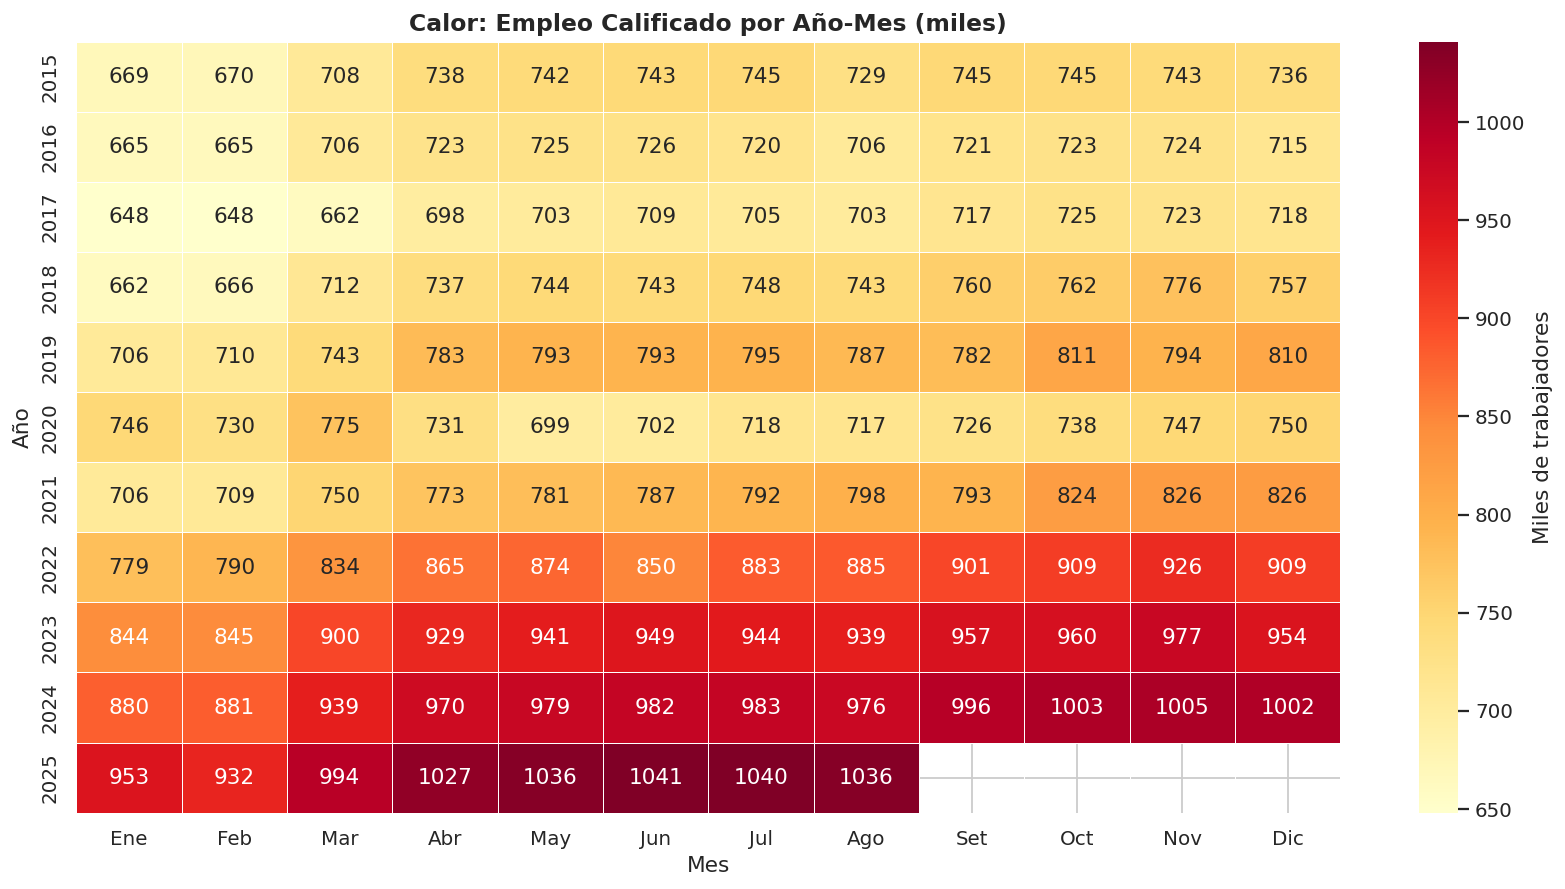

In [10]:
pivot = df.pivot_table(index='anio', columns='mes_num', values='calificado', aggfunc='mean')
pivot.columns = meses_etiquetas[:len(pivot.columns)]

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot/1e3, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Miles de trabajadores'})
ax.set_title('Calor: Empleo Calificado por Año-Mes (miles)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Año')
plt.tight_layout()
plt.show()

## 8. Correlación entre Variables

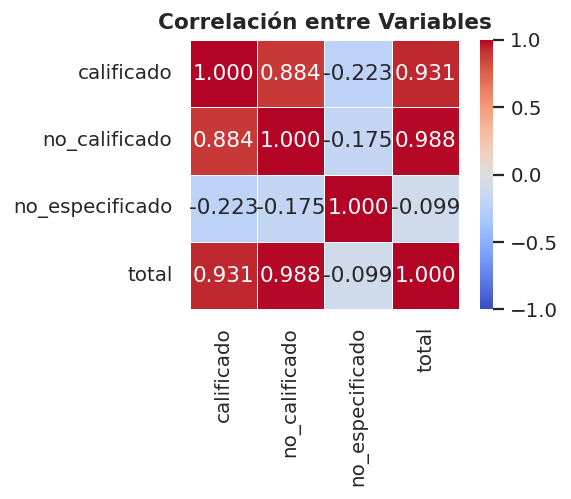

In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
corr = df[['calificado','no_calificado','no_especificado','total']].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlación entre Variables', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Crecimiento Interanual

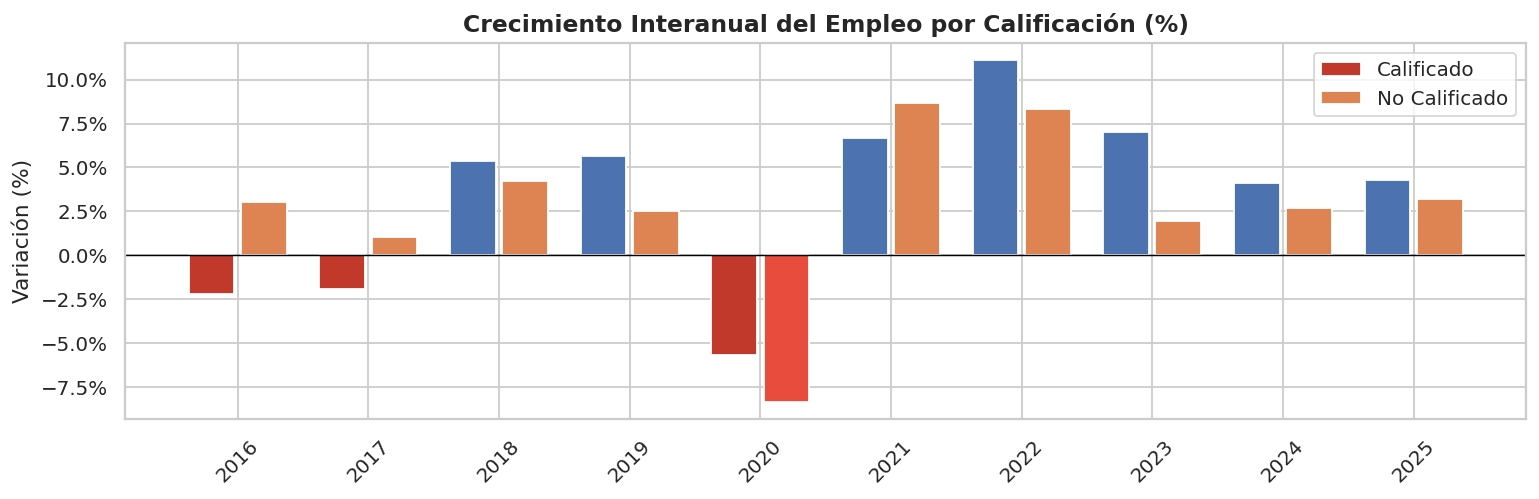

In [12]:
anual_mean = df.groupby('anio')[['calificado','no_calificado']].mean()
crecimiento = anual_mean.pct_change() * 100
crecimiento = crecimiento.dropna()

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(crecimiento))
ax.bar(x - 0.2, crecimiento['calificado'], 0.35, label='Calificado',
       color=[COLORS['calificado'] if v >= 0 else '#c0392b' for v in crecimiento['calificado']])
ax.bar(x + 0.2, crecimiento['no_calificado'], 0.35, label='No Calificado',
       color=[COLORS['no_calificado'] if v >= 0 else '#e74c3c' for v in crecimiento['no_calificado']])
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(crecimiento.index.astype(int), rotation=45)
ax.set_title('Crecimiento Interanual del Empleo por Calificación (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Variación (%)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

## 10. Resumen de Hallazgos

| Métrica | Calificado | No Calificado |
|---------|-----------|---------------|
| Promedio mensual | ~779 K | ~2,890 K |
| Máximo observado | ~1,041 K (Jun 2025) | ~3,427 K (Nov 2024) |
| Mínimo observado | ~648 K (Ene 2017) | ~2,091 K (May 2020) |
| Tendencia | ▲ Creciente | ▲ Creciente |

**Observaciones clave:**
- El empleo **no calificado** representa ~78–80% del empleo total (sin no especificado).
- El **COVID-19 (2020)** generó una caída pronunciada en ambas categorías (especialmente Mar–May 2020).
- El **empleo calificado** muestra una tendencia de crecimiento más fuerte a partir de 2022.
- Hay **estacionalidad clara**: caídas en ENE–FEB y picos en OCT–NOV.